#Ethan Gonsalves  Roll No : 24 SE Aiml


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
iris = datasets.load_iris()
x=iris.data
y=iris.target

features_names=iris.feature_names
print(iris.feature_names)
print()
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

['setosa' 'versicolor' 'virginica']


#PART 1 - DATA SET SUMARRY TABLE

In [3]:
print("DATASET SUMMARY")
print("Number of Samples:",x.shape[0])
print("Number of features:",x.shape[1])
print("Number of Classes:",len(np.unique(y)))
print(features_names)
print()

DATASET SUMMARY
Number of Samples: 150
Number of features: 4
Number of Classes: 3
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']



#PART II FEATURE STATISTIC TABLE

In [4]:
df=pd.DataFrame(x, columns=features_names)

print("FEATURE STATISTICS")
stat_table=pd.DataFrame({
    "Mean": df.mean(),
    "Standard Deviation": df.std()
})

print(stat_table)
print()
print(df.head())
print()

FEATURE STATISTICS
                       Mean  Standard Deviation
sepal length (cm)  5.843333            0.828066
sepal width (cm)   3.057333            0.435866
petal length (cm)  3.758000            1.765298
petal width (cm)   1.199333            0.762238

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2



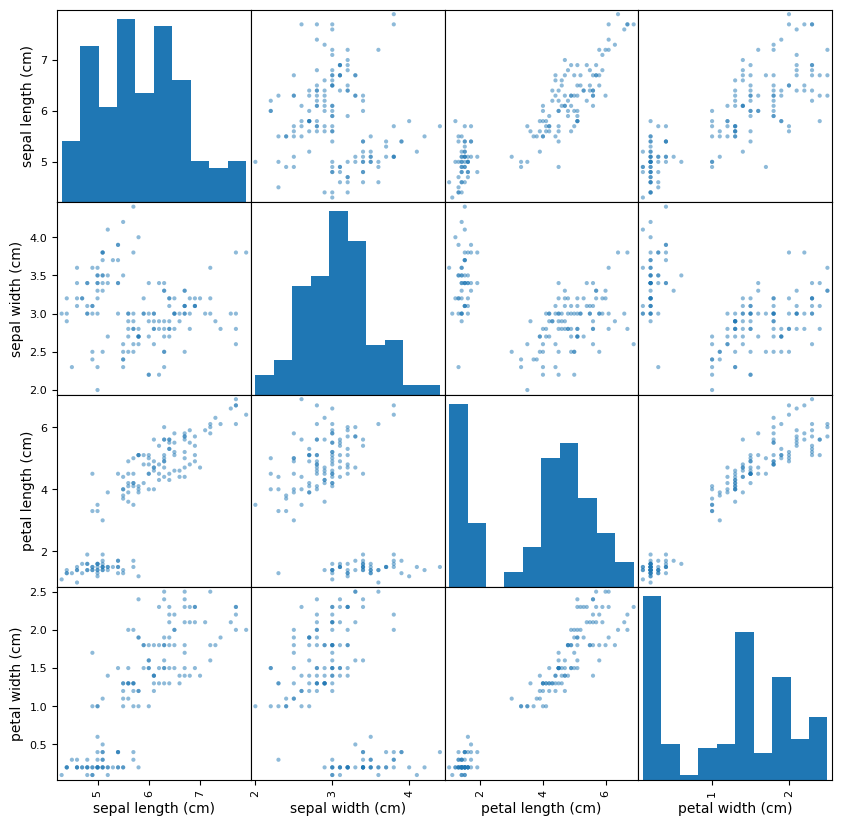

In [5]:
pd.plotting.scatter_matrix(
    df.iloc[:,0:4],
    figsize=(10,10),
    diagonal='hist'
)

plt.show()

#PART III  PCA

In [6]:
sc=StandardScaler()
x_scaled=sc.fit_transform(x)

In [7]:
pca=PCA(n_components=1)
x_pca=pca.fit_transform(x_scaled)

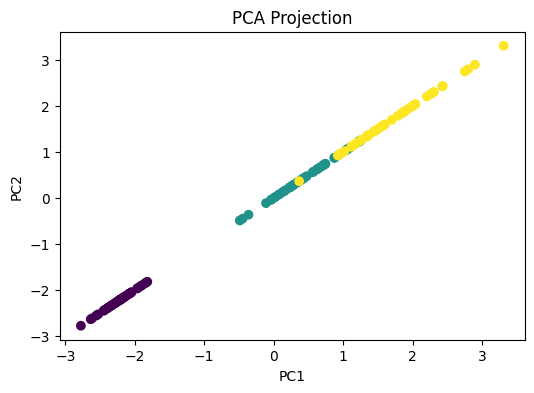

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(x_pca[:,0],x_pca[:,0],c=y)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [9]:
explained_variance=pca.explained_variance_
variance_ratio=pca.explained_variance_ratio_
cumulative_variance=np.cumsum(variance_ratio)

In [10]:
pca_table=pd.DataFrame({
    "Eigenvalue": explained_variance,
    "Explaind Variance (%)": variance_ratio*100,
    "Cumulative Variance (%)": cumulative_variance*100
})

print("PCA VARIANCE TABLE")
print(pca_table)
print()

PCA VARIANCE TABLE
   Eigenvalue  Explaind Variance (%)  Cumulative Variance (%)
0    2.938085              72.962445                72.962445



#Part IV - LDA

In [12]:
lda=LinearDiscriminantAnalysis(n_components=1)
x_lda=lda.fit_transform(x_scaled, y)

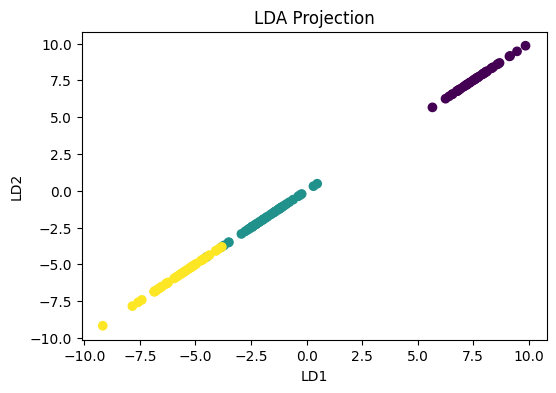

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(x_lda[:,0],x_lda[:,0],c=y)
plt.title("LDA Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

In [14]:
x_train, x_test, y_train, y_test=train_test_split(x_scaled, y , test_size=0.3, random_state=42)

In [15]:
xp_train, xp_test, yp_train, yp_test=train_test_split(x_pca, y , test_size=0.3, random_state=42)

In [16]:
xl_train, xl_test, yl_train, yl_test=train_test_split(x_lda, y , test_size=0.3, random_state=42)

In [17]:
model=KNeighborsClassifier()
#Original Data
start=time.time()
model.fit(x_train,y_train)
train_time_original=time.time()-start

y_pred=model.predict(x_test)
acc_original=accuracy_score(y_test, y_pred)
#PCA Data
start=time.time()
model.fit(xp_train,yp_train)
train_time_pca=time.time()-start

y_pred=model.predict(xp_test)
acc_pca=accuracy_score(yp_test, y_pred)
#LDA Data
start=time.time()
model.fit(xl_train,yl_train)
train_time_lda=time.time()-start

y_pred=model.predict(xl_test)
acc_lda=accuracy_score(yl_test, y_pred)

In [18]:
accuracy_table=pd.DataFrame({
    "Dataset Version":["Original", "PCA Reduced","LDA Reduced"],
    "Accuracy": [acc_original, acc_pca, acc_lda],
    "Training Time (seconds)":[train_time_original, train_time_pca, train_time_lda]
})
print("MODEL PERFORMANCE TABLE")
print(accuracy_table)

MODEL PERFORMANCE TABLE
  Dataset Version  Accuracy  Training Time (seconds)
0        Original  1.000000                 0.007089
1     PCA Reduced  0.911111                 0.001673
2     LDA Reduced  1.000000                 0.001476
